# Linear regression model for house price prediction


### Imports

In [1]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

#### Reading CSV

In [2]:
data = pd.read_csv("data.csv")

In [3]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
data.drop(columns = ['date','street','statezip','country'], inplace = True)

In [5]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [6]:
data = data[data['price'] < 1000000]

data = data[data['sqft_lot'] < 20000] 


In [7]:
Y = data['price']
Y.head()

0    313000.0
2    342000.0
3    420000.0
4    550000.0
5    490000.0
Name: price, dtype: float64

In [8]:
X = data.drop(columns = 'price')

In [9]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,Seattle


In [10]:
encoder = LabelEncoder()

X['city_encoded'] = encoder.fit_transform(X['city']) + 1

In [11]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,city_encoded
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,37
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,19
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,4
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,32
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,Seattle,36


In [12]:
X.drop(columns = 'city', inplace = True)

In [13]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city_encoded
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,37
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,19
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,4
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,32
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,36


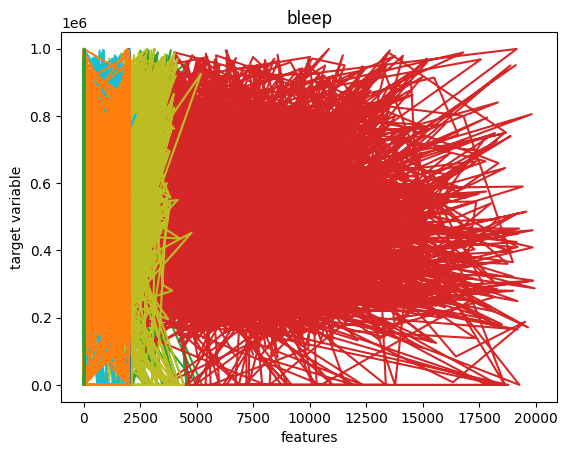

In [14]:
plt.plot(X, Y)

plt.title('bleep')
plt.xlabel('features')
plt.ylabel('target variable')

plt.show()

In [15]:
X['house_age'] = 2026 - X['yr_built']

In [16]:
X.drop(columns = 'yr_built', inplace = True)
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,city_encoded,house_age
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,2005,37,71
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,0,19,60
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,0,4,63
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1992,32,50
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,1994,36,88


In [17]:
X['renovation_age'] = np.where(X['yr_renovated'] > 0, 2026 - X['yr_renovated'], 0 )

In [18]:
X.drop(columns = 'yr_renovated', inplace = True)
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,city_encoded,house_age,renovation_age
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,37,71,21
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,19,60,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,4,63,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,32,50,34
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,36,88,32


In [19]:
X = pd.get_dummies(X, columns= ['city_encoded'], drop_first = True)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [22]:
X

array([[-0.36844447, -0.78941332, -0.81247336, ..., -0.04304454,
        -0.11091778, -0.02299306],
       [-0.36844447, -0.0757075 , -0.00891483, ..., -0.04304454,
        -0.11091778, -0.02299306],
       [-0.36844447,  0.28114541,  0.08642262, ..., -0.04304454,
        -0.11091778, -0.02299306],
       ...,
       [-0.36844447,  0.63799832,  1.46200585, ..., -0.04304454,
        -0.11091778, -0.02299306],
       [ 0.76997374, -0.0757075 ,  0.20899934, ..., -0.04304454,
        -0.11091778, -0.02299306],
       [-0.36844447,  0.63799832, -0.60817882, ..., -0.04304454,
        -0.11091778, -0.02299306]], shape=(3785, 55))

In [24]:
X = pd.DataFrame(X)

print(X.head())

         0         1         2         3         4         5         6   \
0 -0.368444 -0.789413 -0.812473  0.166246  0.022357 -0.048821 -0.252715   
1 -0.368444 -0.075708 -0.008915  1.263761 -0.897449 -0.048821 -0.252715   
2 -0.368444  0.281145  0.086423  0.198342 -0.897449 -0.048821 -0.252715   
3  0.769974  0.637998  0.004705  0.870179 -0.897449 -0.048821 -0.252715   
4 -1.506863 -1.503119 -1.438977 -0.250456 -0.897449 -0.048821 -0.252715   

         7         8         9   ...        45        46        47        48  \
0 -0.670070 -0.461470 -0.678936  ... -0.081541 -0.781872  5.574610 -0.016256   
1  0.820944  0.390470 -0.678936  ... -0.081541 -0.781872 -0.179385 -0.016256   
2  0.820944 -0.952419  1.772444  ... -0.081541 -0.781872 -0.179385 -0.016256   
3  0.820944 -0.750263  1.282168  ... -0.081541 -0.781872 -0.179385 -0.016256   
4 -0.670070 -1.125695 -0.678936  ... -0.081541  1.278982 -0.179385 -0.016256   

         49        50        51        52        53        54  
0 -0

### Model

In [25]:
model = linear_model.LinearRegression()

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [27]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

#### model analysis

In [29]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, y_pred))

Coefficients: [-7.54699627e+03  8.05262159e+03  5.37045492e+04 -8.88192828e+03
  1.67983272e+04 -8.12617625e+03  1.33333604e+04  1.79297032e+04
  4.90294897e+04  1.34261620e+04  2.02122937e+04 -4.56732814e+02
  4.03116396e+03  9.00440517e+03  7.25400901e+04  7.57330512e+03
  1.79499569e+04  1.31198442e+04  4.82076410e+03  6.94354596e+03
  1.51327571e+03  9.68110286e+03  1.15426010e+04  3.28450823e+03
  5.08899405e+03  6.20969687e+03  0.00000000e+00  5.18828582e+04
  2.24158284e+04  9.05827980e+03  5.46961409e+04  1.29097801e+04
  9.85235660e+03 -3.18310323e+03  4.35818005e+04  2.77687864e+03
  2.24293395e+04  6.91660647e+03  1.36164769e+04  2.29313001e+03
  8.65496614e-15  9.03362611e+02  6.84822869e+04  2.61647021e+04
  5.11068254e+04  4.19124028e+03  1.22955665e+05  2.88046425e+04
  5.46562318e-12  2.03730191e+04  4.46433170e+03  2.62636381e+03
  1.06003946e+04  2.26763280e+04  1.53633353e+04]
Intercept: 456422.37611849426
Mean squared error (MSE): 18442596877.22
Coefficient of deter

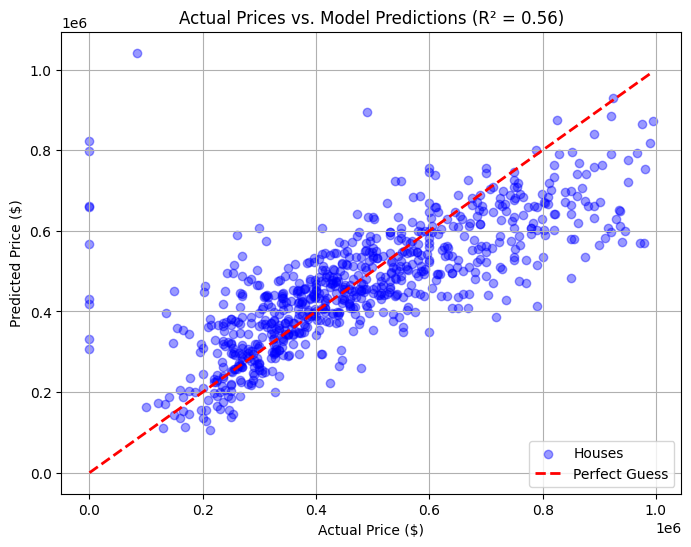

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, model.predict(X_test), alpha=0.4, color='blue', label='Houses')

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Guess')

#label
plt.title('Actual Prices vs. Model Predictions (R² = 0.56)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()
